In [ ]:
%load_ext autoreload
%autoreload 2

: 

# Kinematics

In [2]:
from dataclasses import dataclass
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jaxlie import SE3, SO3
from jax.scipy.spatial.transform import Rotation as Rot

key = jax.random.PRNGKey(0)


# Let a batched SE3 be indexed/sliced like an array (jaxlie doesn't support it).
def _se3_getitem(self, index) -> SE3:
    if not isinstance(index, tuple):
        index = (index,)
    return SE3(self.wxyz_xyz[index + (slice(None),)])  # keep the trailing 7 axis
SE3.__getitem__ = _se3_getitem

def _se3_shape(self) -> tuple:
    return self.wxyz_xyz.shape[:-1]
SE3.shape = property(_se3_shape)

def _se3_reshape(self, shape) -> SE3:
    return SE3(self.wxyz_xyz.reshape(tuple(shape) + (7,)))
SE3.reshape = _se3_reshape

def _se3_broadcast_to(self, shape) -> SE3:
    return SE3(jnp.broadcast_to(self.wxyz_xyz, tuple(shape) + (7,)))
SE3.broadcast_to = _se3_broadcast_to

# Euler / RPY convention.
# > Intrinsic: XYZ (uppercase, moving axes)
# > Extrinsic: xyz (lowercase, fixed).
# jaxlie's SO3.from_rpy_radians(r, p, y) == Rz(y) @ Ry(p) @ Rx(r) (ZYX), and is
# exactly scipy's from_euler("xyz", [r, p, y]) / from_euler("ZYX", [y, p, r]).
def from_te(t, e, seq="xyz") -> SE3:
    """Create an SE3 from a translation ``t`` and Euler angles ``e`` (rpy=xyz)."""
    rpy = Rot.from_euler(seq, e, degrees=False).as_euler("xyz", degrees=False)
    return SE3.from_rotation_and_translation(SO3.from_rpy_radians(rpy[...,0], rpy[...,1], rpy[...,2]), t)
SE3.from_te = staticmethod(from_te)

def _se3_stack(tfs) -> SE3:
    """Create an SE3 from a translation ``t`` and Euler angles ``e`` (rpy=xyz)."""
    return SE3(wxyz_xyz=jnp.stack([tf.wxyz_xyz for tf in tfs], axis=0))
SE3.stack = staticmethod(_se3_stack)





In [3]:
def complement(subset, N=6):
    """Legs in ``range(N)`` not in ``subset``: ``(..., K) -> (..., N-K)``.

    The "free" legs of a stance (not currently planted). Vectorized and
    jit-friendly. E.g. ``complement([0, 2, 4]) -> [1, 3, 5]``.
    """
    subset = jnp.asarray(subset)
    K = subset.shape[-1]
    in_subset = jax.nn.one_hot(subset, N).sum(axis=-2) > 0          # (..., N)
    order = jnp.argsort(in_subset, axis=-1, stable=True)            # not-in-subset first
    return jnp.asarray(order[..., : N - K])


def adjust_angle(theta):
    """Adjust angles to be within [-pi, pi] range."""
    return (theta + jnp.pi) % (2 * jnp.pi) - jnp.pi

## Types

Main types we work with are:
- `Foothold`
- `Stance`
- `Posture`

In [4]:
# Alternative names: ContactSite, SupportSite
@jax.tree_util.register_dataclass
@dataclass
class Foothold: 
    """Location in the environment that is suitable for placing a foot."""
    position: jax.Array
    normal: jax.Array 
    # Zero normal means no contact and a floating position, i.e. 
    # the foothold is not used, but we may store a foot position in there.

    def __getitem__(self, index) -> "Foothold":
        """Index a batched foothold (leading axis) -> a foothold."""
        return Foothold(self.position[index], self.normal[index])

    @property
    def shape(self) -> tuple[int, ...]:
        return self.position.shape[:-1]

    def __iter__(self):
        """Iterate over the leading axis of a batched foothold."""
        for i in range(self.shape[0]):
            yield self[i]

    @property
    def pos(self) -> jax.Array:
        return self.position


# Alternative names: mask = support
@jax.tree_util.register_dataclass
@dataclass
class Stance: 
    support: jax.Array
    feet: jax.Array
    normals: jax.Array

    @property
    def ids(self) -> jax.Array:
        """Indices of the stance's footholds in the pool."""
        return jnp.where(self.support)[0]
    
    def __getitem__(self, index) -> "Stance":
        """Index a batched stance (leading axis) -> a stance."""
        return Stance(self.support[index], self.feet[index], self.normals[index])

    @property
    def shape(self) -> tuple[int, ...]:
        return self.support.shape[:-1]

    def __iter__(self):
        """Iterate over the leading axis of a batched stance."""
        for i in range(self.shape[0]):
            yield self[i]


# Alternative names: Support
@jax.tree_util.register_dataclass
@dataclass
class Posture:
    body: SE3
    thetas: jax.Array
    stance: Stance

    @property
    def feet(self) -> jax.Array:
        """Indices of the stance's footholds in the pool."""
        return self.stance.feet

    def __getitem__(self, index) -> "Posture":
        """Index a batched posture (leading axis) -> a posture."""
        return Posture(self.body[index], self.thetas[index], self.stance[index])

    @property
    def shape(self) -> tuple[int, ...]:
        return self.body.shape

    def __iter__(self):
        """Iterate over the leading axis of a batched posture."""
        for i in range(self.shape[0]):
            yield self[i]

## Forward kinematics

Mapping model state (e.g. `qpos`) to world entities.

In [5]:
#
#   Specifiying a multilegged robot's configuration and kinematics. 
#
NUM_LEGS = 6
RADIUS = 0.15  # circumradius of the hexagon formed by the shoulders

_SHOULDER_ANGLES = jnp.deg2rad(
    jnp.arange(360.0 / NUM_LEGS / 2, 360.0, 360.0 / NUM_LEGS)
)  

SHOULDERS = SE3.from_te(
    RADIUS * jnp.stack([
        jnp.cos(_SHOULDER_ANGLES), 
        jnp.sin(_SHOULDER_ANGLES),
        jnp.zeros(NUM_LEGS)], axis=-1
    ),
    _SHOULDER_ANGLES[:,None], "z"
)

# SHOULDERS = SE3.from_rotation_and_translation(
#     SO3.from_z_radians(_SHOULDER_ANGLES),
#     0.15 * jnp.stack([jnp.cos(_SHOULDER_ANGLES),
#                       jnp.sin(_SHOULDER_ANGLES),
#                       jnp.zeros(NUM_LEGS)], axis=-1),
# )
# FEET_LIFTED = SHOULDERS.apply(jnp.array([LENGTHS[0]+0.2, 0.0, LENGTHS[1]-LENGTHS[2]]))

NUM_JOINTS = 4
LENGTHS = jnp.array([0.025, 0.025, 0.2, 0.25])
ANKLE_LIMIT = jnp.pi/4
# joint axes in the order of the kinematic chain
# hip-yaw, hip-roll, hip-pitch, knee-pitch
AXES = ["z", "x", "y", "y"]  
JOINT_LIMITS = jnp.deg2rad(jnp.array([
    [-80.0,  80.0],    
    [-80.0,  80.0],    
    [-120.0,  120.0],  
    [  0.0, 120.0],  
]))




In [6]:
def _joint(x, theta, axis=AXES):
    return SE3.from_te(jnp.array([x, 0.0, 0.0]), theta, axis)

def _joint_frames(thetas, lengths=LENGTHS, axes=AXES):
    """Maps joint angles to the frames of the joints and the end-effector
    in the world frame. Assuming shoulder link is mounted at the origin of the world frame"""
    num_joints = len(lengths)

    tf = _joint(0.0, thetas[0], axes[0])
    frames = [tf]

    for i in jnp.arange(num_joints-1):
        tf = tf @ _joint(lengths[i], thetas[i+1], axes[i+1])
        frames.append(tf)
    tf = tf @ SE3.from_translation(jnp.array([lengths[-1], 0.0, 0.0]))
    frames.append(tf)
    
    return SE3.stack(frames)

def _forward_model(thetas, lengths=LENGTHS, axes=AXES):
    """Maps joint angles to the positions of the joints and the end-effector
    in the world frame. Assuming shoulder link is mounted at the origin of the world frame"""
    num_joints = len(lengths)

    tf = _joint(0.0, thetas[0], axes[0])
    xpos = [tf.translation()]

    for i in jnp.arange(num_joints-1):
        tf = tf @ _joint(lengths[i], thetas[i+1], axes[i+1])
        xpos.append(tf.translation())
    tf = tf @ SE3.from_translation(jnp.array([lengths[-1], 0.0, 0.0]))
    xpos.append(tf.translation())
    
    return jnp.stack(xpos, axis=0)


### Forward model: reality check

In [7]:
theta = jnp.deg2rad(jnp.array([0.0, 0.0, 90.0, 0.0]))
lengths = jnp.array([0.025, 0.025, 0.2, 0.25])
axes = ["z", "x", "y", "y"]

tibia = _joint_frames(theta, lengths=lengths, axes=axes)[-2].rotation().as_matrix()[:,0]
print(tibia)

ys = _forward_model(theta, lengths, axes)
tibia_ = ys[-2] - ys[-1]
tibia_ = tibia_ / jnp.linalg.norm(tibia_)
print(tibia_)

[ 1.1920929e-07  0.0000000e+00 -9.9999994e-01]
[-8.940697e-08  0.000000e+00  1.000000e+00]


In [8]:
theta = jnp.deg2rad(jnp.array([0.0, 0.0, 90.0, 0.0]))
lengths = jnp.array([0.025, 0.025, 0.2, 0.25])
axes = ["z", "x", "y", "y"]

_forward_model(theta, lengths, axes)

Array([[ 0.        ,  0.        ,  0.        ],
       [ 0.025     ,  0.        ,  0.        ],
       [ 0.05      ,  0.        ,  0.        ],
       [ 0.05000001,  0.        , -0.20000002],
       [ 0.05000003,  0.        , -0.45000002]], dtype=float32)

[[ 0.0000000e+00  0.0000000e+00  0.0000000e+00]
 [ 2.5000000e-02  0.0000000e+00  0.0000000e+00]
 [ 5.0000001e-02  0.0000000e+00  0.0000000e+00]
 [ 8.4729657e-02  0.0000000e+00  1.9696155e-01]
 [ 1.2814173e-01  9.1482441e-08 -4.9240395e-02]]


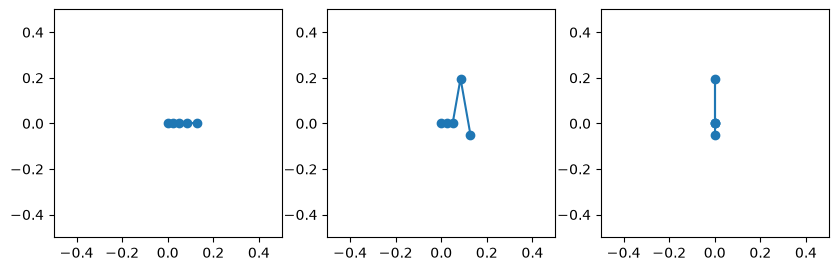

In [9]:
theta = jnp.deg2rad(jnp.array([0.0, 0.0, -80.0, 160.0]))
lengths = jnp.array([0.025, 0.025, 0.2, 0.25])
axes = ["z", "x", "y", "y"]

ys = _forward_model(theta, lengths, axes)



print(ys)
fig, axs = plt.subplots(1, 3, figsize=(10, 5))


for ax in axs:
    ax.set_aspect("equal")
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    
ax = axs[0]
ax.plot(ys[:, 0], ys[:, 1], marker="o")

ax = axs[1]
ax.plot(ys[:, 0], ys[:, 2], marker="o")

ax = axs[2]
ax.plot(ys[:, 1], ys[:, 2], marker="o")


In [10]:
# #
# #   Forward kinematics for a single leg
# #
# def _compute_joint_xpos(shoulder, theta, lengths=LENGTHS) -> jax.Array:
#     coxa = from_te(jnp.array([0.0, 0.0, 0.0]), jnp.array([0., 0., theta[0]]))
#     femur = from_te(jnp.array([lengths[0], 0.0, 0.0]), jnp.array([0., theta[1], 0.]))
#     tibia = from_te(jnp.array([lengths[1], 0.0, 0.0]), jnp.array([0., theta[2], 0.]))
#     foot = from_te(jnp.array([lengths[2], 0.0, 0.0]), jnp.zeros(3))
#     coxa_pos = (shoulder @ coxa).translation()
#     femur_pos = (shoulder @ coxa @ femur).translation()
#     tibia_pos = (shoulder @ coxa @ femur @ tibia).translation() 
#     foot_pos = (shoulder @ coxa @ femur @ tibia @ foot).translation()
#     return jnp.stack([coxa_pos, femur_pos, tibia_pos, foot_pos], axis=0)  # (4, 3)

# # TODO: define a factory for this type of function taking a lengths array and an joints (what's a better name?) array specifying the (normal) axis of the joints.
# # In the case above, the axes are ["z", "y", "y"].

# def compute_joint_xpos(body: SE3, thetas: jax.Array, lengths=LENGTHS) -> jax.Array:
#     """Return the world positions of the joints (coxa, femur, tibia) for each leg."""
#     shoulders = body @ SHOULDERS
#     return jax.vmap(_compute_joint_xpos, in_axes=(0, 0, None))(shoulders, thetas, lengths) 

# def _compute_foot_vector(shoulder: SE3, theta: jax.Array, lengths=LENGTHS) -> jax.Array:
#     """Return the world vectors foot to knee"""
#     joint_xpos = _compute_joint_xpos(shoulder, theta, lengths)
#     v = joint_xpos[-2] - joint_xpos[-1]
#     return v/jnp.linalg.norm(v)

# def compute_foot_vector(body: SE3, thetas: jax.Array, lengths=LENGTHS) -> jax.Array:
#     """Return the world vectors foot to knee"""
#     shoulders = body @ SHOULDERS
#     return jax.vmap(_compute_foot_vector, in_axes=(0, 0, None))(shoulders, thetas, lengths)

## Inverse Kinematics

$$
\alpha =\arccos \left(\frac{b^{2}+c^{2}-a^{2}}{2bc}\right)
$$
$$
\beta =\arccos \left(\frac{a^{2}+c^{2}-b^{2}}{2ac}\right)
$$
$$
\gamma =\arccos \left(\frac{a^{2}+b^{2}-c^{2}}{2ab}\right)
$$

In [11]:
def _infer_theta(shoulder: SE3, foot: jax.Array, normal: jax.Array, lengths: jax.Array=LENGTHS) -> tuple[jax.Array, jax.Array]:
    """Like :func:`_infer_theta`, but yaw and roll are solved *jointly*.

    The leg's flexion plane (the x-z plane of the frame after yaw@roll) must contain
    both the foot and the surface normal, so its out-of-plane axis is
    ``y_hat = normalize(p x n)``. The femur base lies on the plane's x-axis (the
    coxa/roll offset is along ``x_hip`` and roll is about x, so it cancels), hence
    the plane passes through the shoulder origin and this is exact. yaw/roll are read
    back from ``y_hat``; the planar femur/knee solve is unchanged.

    Fixes the old bug where yaw (from the foot azimuth) and roll (from the normal)
    were picked independently, leaving the foot off the tilted plane by its
    out-of-plane component and mislocating it for non-vertical normals.
    """
    p = shoulder.inverse().apply(foot)
    n = shoulder.rotation().inverse().apply(normal)

    # Flexion-plane out-of-plane axis: perpendicular to both the foot and the normal.
    yhat = jnp.cross(p, n)
    yhat = yhat / (jnp.linalg.norm(yhat) + 1e-12)
    yhat = jnp.where(yhat[1] < 0, -yhat, yhat)       # sign -> coxa forward, yaw in [-pi/2, pi/2]

    # y_hat = [-sin(yaw)cos(roll), cos(yaw)cos(roll), sin(roll)]
    yaw = jnp.arctan2(-yhat[0], yhat[1])
    roll = jnp.arctan2(yhat[2], jnp.sqrt(yhat[0]**2 + yhat[1]**2))

    hip = (
        _joint(0.0, yaw, "z") @
        _joint(lengths[0], roll, "x") @
        _joint(lengths[1], 0.0, "y")
    )

    u0, u1 = hip.inverse().apply(p)[jnp.array([0, 2])]

    # a = reach in the flexion plane, b = femur, c = tibia
    a = jnp.sqrt(u0**2 + u1**2)
    b = lengths[2]
    c = lengths[3]

    reachable = (
        (a <= (b + c)) &
        (a >= jnp.abs(b - c))
    )

    offset = jnp.arctan2(u1, u0)
    alpha = jnp.arccos(
        (c**2 + b**2 - a**2) / (2 * c * b)
    )
    gamma = jnp.arccos(
        (b**2 + a**2 - c**2) / (2 * b * a)
    )

    # This orders the remaining branch by elbow down first.
    theta = jnp.array([
        [yaw, roll,  -(offset + gamma), -(-jnp.pi + alpha)],
        [yaw, roll, -(offset - gamma),  -jnp.pi + alpha],
    ])

    return reachable, theta[0, :]


def infer_theta(body, feet, normals, lengths=LENGTHS, shoulders=SHOULDERS) -> tuple[jax.Array, jax.Array]:
    reachable, theta = jax.vmap(_infer_theta, in_axes=(0, 0, 0, None))(
        body@shoulders, feet, normals, lengths)

    return reachable, theta



def reality_check(key, num_samples=10):

    axes = ["z", "x", "y", "y"]
    shoulder = SE3.identity()
    lengths = jnp.array([0.025, 0.025, 0.2, 0.25])

    key, subkey = jax.random.split(key)
    keys = jax.random.split(subkey, 2)
    xs = jax.random.uniform(keys[0], (num_samples, 3), minval=-0.2, maxval=0.2)
    ns = jax.random.normal(keys[1], (num_samples, 3))
    ns = ns / jnp.linalg.norm(ns, axis=-1, keepdims=True)

    reachable, theta = jax.vmap(lambda x,n: _infer_theta(shoulder, x, n, lengths))(xs, ns)
    reachable = jnp.all(reachable, axis=-1)
    ys = jax.vmap(lambda t: _forward_model(t, lengths, axes))(theta)
    xs_ = ys[:,-1] 

    print(xs)
    print(xs_)

    return jnp.all(reachable), jnp.allclose(xs, xs_, atol=1e-2)

In [12]:
key, = jax.random.split(key, 1)
reality_check(key, num_samples=3)

[[-0.193467    0.1351244  -0.05587215]
 [-0.18814503 -0.13670316 -0.03630247]
 [-0.17463084 -0.05051651  0.09546299]]
[[-0.19346693  0.13512442 -0.05587207]
 [-0.18814504 -0.13670313 -0.03630248]
 [-0.17463073 -0.05051649  0.09546297]]


(Array(True, dtype=bool), Array(True, dtype=bool))

In [13]:
FEET_LIFTED = SHOULDERS.apply(_forward_model(
    jnp.deg2rad(jnp.array([0.0, 0.0, -80.0, 160.0])), 
    LENGTHS, AXES)[-1])
FEET_LIFTED 


def infer_posture(body, stance: Stance, *, feet_lifted=FEET_LIFTED):
    """Infer the joint angles of a posture given the body pose and stance."""

    # Lifted legs have a home position. 
    feet = jnp.where(stance.support[:, None], 
                     stance.feet, 
                     body@feet_lifted)  
    normals = jnp.where(stance.support[:, None], 
                        stance.normals, 
                        body.apply(jnp.array([[0.0, 0.0, 1.0]]))) 

    reachable, theta = infer_theta(body, feet, normals) 

    # in_limits = (joint_limits[:,0] <= theta) & (theta <= joint_limits[:,1])  
    # in_ankle_limits = jax.vmap(angle_between)(infer_foot_vectors(body, theta), stance.normals)
    # valid = (
    #     jnp.all(reachable, where=stance.support) & 
    #     jnp.all(in_limits, where=stance.support[:,None]) &
    #     jnp.all(in_ankle_limits <= ankle_limit, where=stance.support)
    # )

    valid = jnp.all(reachable, where=stance.support)

    return valid, Posture(body, theta, Stance(stance.support, feet, stance.normals))

### Reality check

In [14]:
key = jax.random.PRNGKey(0)

In [15]:
axes = ["z", "x", "y", "y"]
shoulder = SE3.identity()
lengths = jnp.array([0.025, 0.025, 0.2, 0.25])

key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, 2)
xs = jax.random.uniform(keys[0], (10, 3), minval=-0.2, maxval=0.2)
ns = jax.random.normal(keys[1], (10, 3))
ns = ns / jnp.linalg.norm(ns, axis=-1, keepdims=True)

reachable, theta = jax.vmap(lambda x,n: _infer_theta(shoulder, x, n, lengths))(xs, ns)
ys = jax.vmap(lambda t: _forward_model(t, lengths, axes))(theta)
xs_ = ys[:,-1] 


print(xs.shape, xs_.shape)
print(jnp.all(reachable), jnp.allclose(xs, xs_, atol=1e-3))


(10, 3) (10, 3)
True True


valid: True
theta: [ 0.        -0.        -1.5707964  2.4980917]


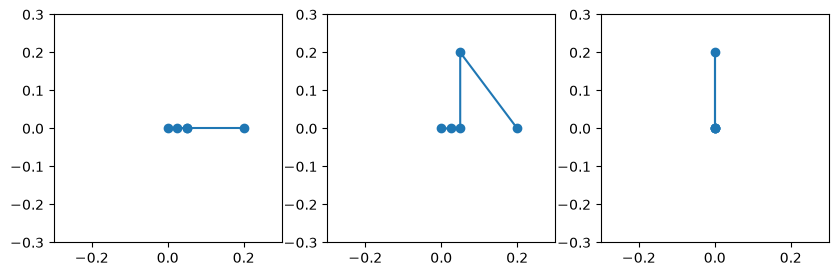

In [16]:
axes = ["z", "x", "y", "y"]
shoulder = SE3.identity()
foot = jnp.array([0.2, 0.0, 0.0])
normal = jnp.array([0.0, 0.0, 1.0])
lengths = jnp.array([0.025, 0.025, 0.2, 0.25])

valid, theta = _infer_theta(shoulder, foot, normal, lengths)
print("valid:", valid)
print("theta:", theta)

ys = _forward_model(theta, lengths, axes)



fig, axs = plt.subplots(1, 3, figsize=(10, 5))


for ax in axs:
    ax.set_aspect("equal")
    ax.set_xlim(-0.3, 0.3)
    ax.set_ylim(-0.3, 0.3)
    
ax = axs[0]
ax.plot(ys[:, 0], ys[:, 1], marker="o")

ax = axs[1]
ax.plot(ys[:, 0], ys[:, 2], marker="o")

ax = axs[2]
ax.plot(ys[:, 1], ys[:, 2], marker="o")



In [17]:
# shoulder = SHOULDERS[0]



# key, _ = jax.random.split(key)
# us = jax.random.uniform(key, shape=(100,3), 
#                         minval=jnp.array([-0.25, -0.02, -0.2]), 
#                         maxval=jnp.array([-0.3,  0.02,  0.2]) )


# limits = jnp.deg2rad(jnp.array([
#     [-80, 80],    # coxa   (yaw)
#     [-120, 120],    # femur  (lift - pitch
#     [  0, 180],          # tibia  (knee - pitch
# ]))
# print(limits)

# reachable, theta = jax.vmap(_infer_theta, (None, 0, None))(shoulder, shoulder.apply(us), LENGTHS)

# in_limits = jnp.all((limits[:, 0] <= theta) & (theta <= limits[:, 1]), axis=-1) 
# mask = reachable & in_limits

# print(theta[0])
# print(f"""
# mask: {mask.shape}
# mask.sum(): {mask.sum()}
# """)


# fig, axs = plt.subplots(1, 2, figsize=(10, 5))


# ax = axs[0]
# ax.set_xlim(-0.3, 0.3)
# ax.set_ylim(-0.3, 0.3)
# ax.scatter(us[:, 0], us[:, 2], c=mask, s=10, vmin=0, vmax=1)

# ax = axs[1]
# ax.set_xlim(-0.3, 0.3)
# ax.set_ylim(-0.3, 0.3)
# ax.scatter(us[:, 0], us[:, 1], c=mask, s=10, vmin=0, vmax=1)



## Samples

In [18]:
from lab.retired.posture.utils import sample_mesh


def sample_footholds(key, vertices, faces, M=50_000):
    """Sample footholds from a mesh.

    Args:
        key: PRNGKey
        vertices: (V, 3) mesh vertices
        faces: (F, 3) mesh faces
        M: number of samples
    Returns:
        xs: (M, 3) sampled foothold positions
        ns: (M, 3) sampled foothold normals
    """
    key, subkey = jax.random.split(key)
    xs, ns = sample_mesh(subkey, vertices, faces, M=M)
    return Foothold(xs, ns)

In [19]:
def sample_support_ids(key, n, num_legs=NUM_LEGS):
    """Sample a stance (indices only) of n legs from the available legs."""
    return jax.random.choice(key, num_legs, shape=(n,), replace=False)

def sample_support(key, n, num_legs=NUM_LEGS):
    """Sample a stance (indices only) of n legs from the available legs."""
    stance = jax.random.choice(key, num_legs, shape=(n,), replace=False)
    return jnp.zeros(num_legs, dtype=bool).at[stance].set(True)


def sample_stance(key, footholds, reachability_masks, support):
    """Sample a stance (indices only) of n legs from the available legs."""
    num_legs = support.shape[0]
    ids = jnp.where(support)[0]
    keys = jax.random.split(key, len(ids))
    probs = reachability_masks/reachability_masks.sum(axis=1, keepdims=True)

    inds = jax.vmap(
        lambda key, i: jax.random.choice(key, footholds.shape[0], p=probs[i]))(
            keys, ids)

    positions = jnp.zeros((num_legs,3)).at[ids,:].set(footholds.position[inds,:])
    normals = jnp.zeros((num_legs,3)).at[ids,:].set(footholds.normal[inds,:])
    
    return Stance(support, positions, normals)

In [20]:
def _sample_box(key, center, spec, N):
    """Uniform samples in a box around ``center``.

    ``spec`` is either a symmetric half-width (scalar or ``(3,)`` delta, so the box
    is ``center +/- spec``) or a ``(3, 2)`` ``[lo, hi]`` offset range per axis (box
    is ``center + [lo, hi]``, allowing asymmetric bounds). ``delta d`` == range
    ``[-d, +d]``.
    """
    spec = jnp.asarray(spec)
    if spec.ndim <= 1:                                  # scalar / (3,) delta -> symmetric
        lo, hi = center - spec, center + spec
    else:                                               # (3, 2) [lo, hi] offset range
        lo, hi = center + spec[:, 0], center + spec[:, 1]
    return jax.random.uniform(key, (N, 3), minval=lo, maxval=hi)


def body_sampler(key, body0, xyz_delta, rpy_delta, N=100):
    """Sample ``N`` bodies uniformly in a box around ``body0``.

    ``xyz_delta`` / ``rpy_delta`` are each either a ``(3,)`` symmetric half-width
    (delta) or a ``(3, 2)`` ``[lo, hi]`` offset range per axis (see ``_sample_box``).
    """
    x0 = body0.translation()
    rpy0 = jnp.asarray(body0.rotation().as_rpy_radians())

    key_xyz, key_rpy = jax.random.split(key)
    xs = _sample_box(key_xyz, x0, xyz_delta, N)
    rpys = _sample_box(key_rpy, rpy0, rpy_delta, N)
    bodies = jax.vmap(from_te)(xs, rpys)

    return bodies

def sample_body(key, body0, xyz_limits, rpy_limits, seq="xyz", N=1):
    """Sample a single body uniformly in a box around ``body0``."""
    x0 = body0.translation()
    rpy0 = jnp.asarray(body0.rotation().as_rpy_radians())

    key_xyz, key_rpy = jax.random.split(key)
    xs = _sample_box(key_xyz, x0, xyz_limits, N)
    rpys = _sample_box(key_rpy, rpy0, rpy_limits, N)
    bodies = SE3.from_te(xs, rpys, seq)
    return bodies


# Exp

Negative torque for the pitch joints, means straightening the leg (lifting, extending). 
Positive torque means bending.

In [21]:
from lab.retired.posture.utils import angle_between

def tibia_vector(shoulder, theta, lengths=LENGTHS):
    """Return the world vectors foot to knee"""
    tibia_frame = shoulder @ _joint_frames(theta, lengths)[-2]
    return tibia_frame.rotation().as_matrix()[:, 0]

In [22]:
def _leg_reach_mask(shoulder, footholds, joint_limits=JOINT_LIMITS, lengths=LENGTHS, ankle_limit=ANKLE_LIMIT):
    """Per-pool-point IK feasibility for one leg: in the reach annulus AND in
    joint limits on the elbow-down branch.

    Args:
        shoulder: SE3 world pose of the leg's shoulder frame.
        footholds: (M,) terrain surface points.

    Returns:
        (M,) bool mask -- whether each point is a feasible foothold for this leg.
    """

    
    reachable, theta = jax.vmap(_infer_theta, (None, 0, 0, None))(
        shoulder, footholds.position, footholds.normal, lengths)
    
    in_lim = jnp.all((joint_limits[None,:, 0] <= theta) & 
                     (theta <= joint_limits[None,:, 1]), 
                     axis=-1)

    tibia = jax.vmap(tibia_vector, (None, 0, None))(shoulder, theta, lengths)
    angles = jax.vmap(angle_between)(-tibia, footholds.normal)
    in_ankle_lim = angles <= ankle_limit

    

    return reachable & in_lim & in_ankle_lim


def leg_reach_mask(body, footholds, joint_limits=JOINT_LIMITS):
    """Per-pool-point IK feasibility for all 6 legs.

    Args:
        body: SE3 world pose of the robot body.
        footholds: (M,) terrain surface points.
    """
    shoulders = body @ SHOULDERS                                     # (6,) SE3
    return jax.vmap(_leg_reach_mask, (0, None, None))(shoulders, footholds, joint_limits)  # (6, M)


In [23]:
import lab.retired.posture.rerun_viz as rrv
from lab.retired.posture.utils import face_normals, vertex_normals
from lab.retired.posture.forces import (
    posture_forces as _posture_forces, 
    posture_wrenches as _posture_wrenches,
    posture_sigma_min as _posture_sigma_min,
    to_qpos, 
    load_model,
    self_collision as _self_collision,
)

model, fids = load_model()
posture_forces = jax.jit(lambda posture: _posture_forces(model, fids, posture))
posture_forces_batch = jax.jit(jax.vmap(posture_forces))
posture_wrenches = jax.jit(lambda posture: _posture_wrenches(model, fids, posture))
posture_wrenches_batch = jax.jit(jax.vmap(posture_wrenches))
posture_sigma_min = jax.jit(lambda posture: _posture_sigma_min(model, fids, posture, length=RADIUS))
posture_sigma_min_batch = jax.jit(jax.vmap(posture_sigma_min))


self_collision_batch = jax.jit(jax.vmap(
    lambda posture: _self_collision(posture, leg_radius=0.05, foot_radius=0.04)))

key = jax.random.PRNGKey(0) 

# Test Surface mesh
vertices = jnp.array([
    [-1.0, -1.0, 0.0],
    [1.0, -1.0, 0.0],
    [1.0, 1.0, 0.0],
    [-1.0, 1.0, 0.0],
    [1.0,-1.0,2.0],
    [1.0,1.0,2.0],
 ])
faces = jnp.array([
    [0, 1, 2],
    [0, 2, 3],
    [1, 4, 5],
    [1, 5, 2],
])
mesh = (vertices, faces)

key,_ = jax.random.split(key)
footholds = sample_footholds(key, *mesh, M=10_000)

# ==============================================================
rrv.init_viewer(connect=8812) 
rrv.set_time(0, timeline="t")
rrv.log_mesh("mesh", *mesh, color=[(210, 210, 210,10)])
rrv.log_contacts("footholds", footholds.position, footholds.normal, 
                 color=[(252, 186, 3)], 
                 normal_color=[(0, 0, 255)],)

In [24]:
body = SE3.from_te(
    jnp.array([0.0, 0.0, .2]), 
    jnp.deg2rad(jnp.array([0.0, 0.0, 0.0])),
    "XYZ"
)

In [25]:
infer_posture_jit = jax.jit(infer_posture)

In [26]:
# body = SE3.from_te(
#     jnp.array([0.9, 0.0, 1.]), 
#     jnp.deg2rad(jnp.array([0.0, -45.0, -30.0])),
#     "XYZ"
# )
body = SE3.from_te(
    jnp.array([0.9, 0.0, 1.]), 
    jnp.deg2rad(jnp.array([0.0, 0.0, -30.0])),
    "XYZ"
)

limits = jnp.deg2rad(jnp.array([
    [-80.0,  80.0],    
    [-80.0,  80.0],    
    [-120.0,  120.0],  
    [  0.0, 120.0],  
]))



support = jnp.array([0, 0, 1, 1, 1, 0], dtype=bool)  
mask = leg_reach_mask(body, footholds, joint_limits=limits)
mask_any = jnp.any(mask, axis=0)


print(f"Reachable footholds: {mask_any.sum()} / {mask_any.shape[0]}")
print(f"Reachable footholds per leg: {mask.sum(axis=1)} / {mask.shape[1]}")
print(f"Reachable footholds per support leg: {mask[jnp.where(support)[0]].sum(axis=1)} / {mask.shape[1]}")

key, _ = jax.random.split(key)


stance = sample_stance(key, footholds, mask, support)
%timeit -n 1 -r 1 jax.block_until_ready(infer_posture_jit(body, stance))
valid, posture = infer_posture_jit(body, stance)
print(f"support: {stance.support}")
print(f"valid: {valid}")

%timeit -n 1 -r 1 jax.block_until_ready(posture_wrenches(posture))
frc, mom, tau = posture_wrenches(posture)

# ==============================================================
rrv.set_time(0, timeline="t")
rrv.log_contacts("reachable_footholds", footholds.position[mask_any], footholds.normal[mask_any], 
                 color=[(200, 200, 200)], 
                 normal_color=[(0, 0, 255)],)
rrv.log_spheres("chosen_footholds", stance.feet, radii=0.01, color=[(255, 0, 0)])
rrv.log_posture("posture", posture, frc=frc, tau=tau, mom=mom, body_color=[(100, 100, 100)],
                link_color=[(250, 250, 250)], hide_free=True,
                disk_radius=0.03, disk_thickness=0.01,  link_width=0.04,
                foot_radius=0.04,
                )

Reachable footholds: 316 / 10000
Reachable footholds per leg: [  0   0 203 145 212   0] / 10000
Reachable footholds per support leg: [203 145 212] / 10000
266 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
support: [False False  True  True  True False]
valid: True


/Users/mirkoklukas/Workspace/control-kit/.venv/lib/python3.13/site-packages/jax/_src/core.py:665: RuntimeWarning: overflow encountered in cast
  c_arg = dtypes.canonicalize_value(arg)


1.33 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [ ]:
S = 30_000
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, S)
stances = jax.vmap(sample_stance, (0,None,None,None))(keys, footholds, mask, support)
valid, postures = jax.vmap(infer_posture, (None, 0))(body, stances)

colliding = self_collision_batch(postures)
valid = valid & ~colliding

frc, tau = posture_forces_batch(postures)
sigs = posture_sigma_min_batch(postures)

print(stances.shape, valid.shape, tau.shape, frc.shape)
print(f"Valid postures: {valid.sum()} / {valid.shape[0]}")
print(f"Colliding postures: {colliding.sum()} / {colliding.shape[0]}")

(30000,) (30000,) (30000, 6, 4) (30000, 6, 3)
Valid postures: 2921 / 30000
Colliding postures: 27079 / 30000


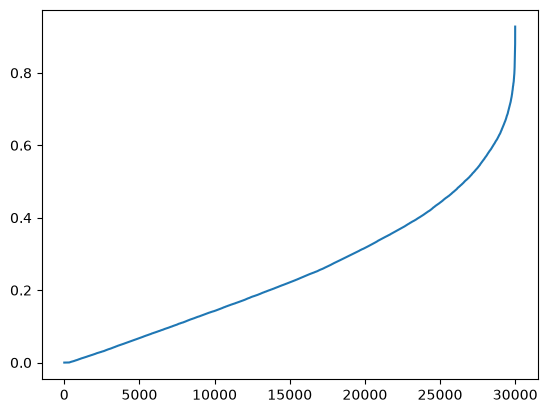

In [28]:
plt.plot(jnp.sort(sigs))

In [29]:
# frcnorm = jnp.linalg.norm(frc, axis=(-2,-1))
# taunorm = jnp.linalg.norm(tau, axis=(-2,-1))
frcnorm = jnp.max(frc, axis=(-2,-1))
taunorm = jnp.max(tau, axis=(-2,-1))

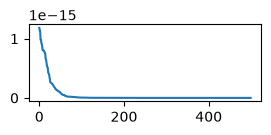

In [30]:


wf, wt, ws = 1.0, 0.0, 0.0
scores = wf*jnp.exp(-frcnorm ) + wt*jnp.exp(-taunorm/20) + ws*(1 - jnp.exp(-sigs))
scores = scores * valid.astype(jnp.float32)


order = jnp.argsort(scores)[::-1]

plt.figure(figsize=(3,1))
plt.plot(scores[order[:500]])

In [31]:
frcnorm[order[0]]

Array(34.371643, dtype=float32)

In [32]:
# frc, mom, tau = posture_wrenches_batch(postures)
frc, tau = posture_forces_batch(postures)

for t,i in enumerate(order[:100]):

    rrv.set_time(t, timeline="t")
    rrv.log_posture(f"posture_sample", postures[i], frc=frc[i], tau=tau[i], body_color=[(100, 100, 100)],
                    link_color=[(250, 250, 250)], hide_free=True,
                    disk_radius=0.03, disk_thickness=0.01,  link_width=0.04,
                    foot_radius=0.04, tmin=-8, tmax=8,
                    )


0.67248106
0.35223877
7.935628
0.43423313


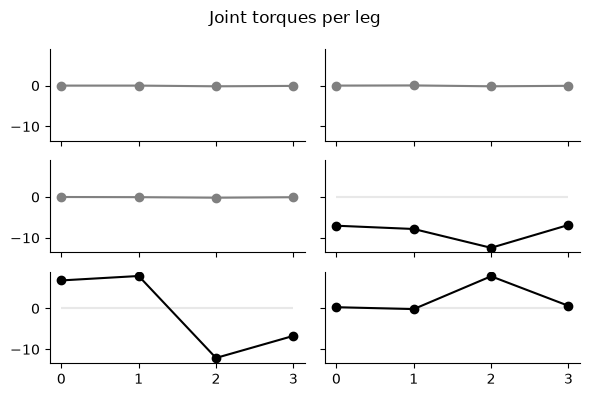

In [33]:
# t=41
t=2
i = order[t]
# print(stances[i])
print(jnp.exp(-taunorm[i]/20.) )
print((1 - jnp.exp(-sigs[i])))
print(taunorm[i])
print(sigs[i])
# =========
fig, axs = plt.subplots(3, 2, figsize=(6, 4), sharex=True, sharey=True)
fig.suptitle("Joint torques per leg")
for ai,l in enumerate([0,1,2,5,4,3]):
    ax = axs[ai%3, ai//3]
    # remove right and top borders
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.hlines(0, 0, 3, color="lightgray", alpha=0.5, linestyle="-")

    color = "black"
    if not postures[order[9]].stance.support[l]:
        color = "gray"

    ax.plot(tau[order[t]][l], color=color, marker="o")

fig.tight_layout()


## Body resample

In [ ]:
t = 0
i = order[t]
xyz_limits = jnp.array([
    [-0.01, 0.01], 
    [-0.01, 0.01], 
    [0.0, 0.0]])
rpy_limits = jnp.deg2rad(jnp.array([
    [-1, 1],
    [-90, 0],
    [0, 0],
]))
# bodies = body_sampler(key, SE3.identity(), xyz_delta=xyz_limits, rpy_delta=rpy_limits, N=100)
bodies = sample_body(key, postures[i].body, xyz_limits, rpy_limits, seq="XYZ", N=10)

valid, test_postures = jax.vmap(infer_posture, (0, None))(bodies, postures[i].stance)
frc, tau = posture_forces_batch(test_postures)

print(valid.shape)
print(f"Valid test postures: {valid.sum()} / {valid.shape[0]}")

test_order = jnp.argsort(valid.astype(jnp.float32))
# ==============================================================
for t,i in enumerate(test_order[:10]):
    rrv.set_time(t, timeline="t")
    rrv.log_posture(f"test_posture_sample", test_postures[i], frc=frc[i], tau=tau[i], body_color=[(100, 100, 100)],
                    link_color=[(250, 250, 250)], hide_free=True,
                    disk_radius=0.03, disk_thickness=0.01,  link_width=0.04,
                    foot_radius=0.04, tmin=-8, tmax=8,
                    )

(10,)
Valid test postures: 10 / 10


2026-07-13T20:20:27.912391Z ERROR re_grpc_client::write: Write messages call failed: transport error


In [65]:
t = 0
i = order[t]

In [ ]:
from lab.retired.posture.forces import posture_wrenches


frc, mom, tau = posture_wrenches(model, fids, postures[i])




/Users/mirkoklukas/Workspace/control-kit/.venv/lib/python3.13/site-packages/jax/_src/core.py:665: RuntimeWarning: overflow encountered in cast
  c_arg = dtypes.canonicalize_value(arg)


(6, 3)

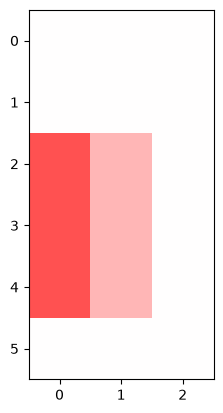

In [83]:
plt.imshow(mom, cmap="bwr", vmin=-10, vmax=10)

(6, 3) (6, 3)


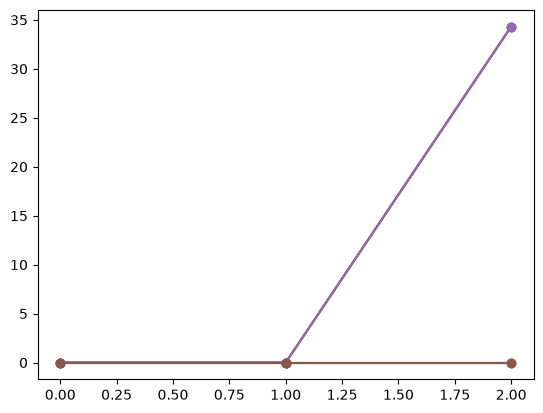

In [76]:
print(frc.shape, mom.shape)


plt.plot(frc.T, marker="o")

In [54]:
postures[order[0]]

Posture(body=SE3(wxyz=[ 0.96593  0.       0.      -0.25882], xyz=[0.9 0.  1. ]), thetas=Array([[ 5.4528550e-07,  2.4537849e-07, -1.3962628e+00,  2.7925267e+00],
       [-1.3697174e-01,  3.4142318e-01, -1.3556199e+00,  2.7890341e+00],
       [ 1.0471979e+00,  1.0782157e+00,  1.4457796e+00,  1.7180340e+00],
       [ 2.9802322e-07, -7.3252147e-01,  1.8711015e+00,  1.5420625e+00],
       [-1.0471976e+00, -7.7788293e-01,  1.4978389e+00,  1.9335073e+00],
       [ 1.3697232e-01, -3.4142318e-01, -1.3556200e+00,  2.7890346e+00]],      dtype=float32), stance=Stance(support=Array([False, False,  True,  True,  True, False], dtype=bool), feet=Array([[ 1.1781417e+00,  6.7055225e-08,  9.5075959e-01],
       [ 1.0390708e+00,  2.4087782e-01,  9.5075959e-01],
       [ 1.0000000e+00, -4.0049553e-02,  9.0878487e-01],
       [ 1.0000000e+00,  8.2916498e-02,  9.0781617e-01],
       [ 1.0000000e+00, -4.0049553e-02,  9.0878487e-01],
       [ 1.0390708e+00, -2.4087781e-01,  9.5075959e-01]], dtype=float32), nor

In [36]:
frc[order[32]]

Array([[ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00],
       [-1.4147129e-02,  1.0145705e-03,  3.4358047e+01],
       [ 3.5302155e-03, -2.4886016e-04,  3.4306099e+01],
       [ 1.0620785e-02, -7.5967365e-04,  3.4278782e+01],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00]], dtype=float32)

In [38]:
tau[order[32]]

Array([[ 0.0000000e+00, -3.2596290e-08, -1.7803210e-01, -7.7272415e-02],
       [ 0.0000000e+00, -4.2210907e-02, -1.7416793e-01, -5.7424486e-02],
       [ 3.5338651e-04,  2.8906763e+00, -4.3084950e+00, -4.4852624e+00],
       [ 1.6197083e-03, -1.3380165e+00, -6.7439599e+00, -4.6354771e+00],
       [ 1.2595239e-03, -1.5979191e+00, -4.3987994e+00, -4.7520723e+00],
       [ 0.0000000e+00,  4.2210877e-02, -1.7416796e-01, -5.7424426e-02]],      dtype=float32)